# **Diversity analysis in Music and Entertainment categories on YouTube**

In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import src.utils.plot_config
import matplotlib.pyplot as plt
from tqdm import tqdm
import swifter
import src.utils.data_utils as data_utils
import src.utils.diversity_utils as diversity_utils

# Enable tqdm progress bar for pandas
tqdm.pandas()

In [3]:
ROOT_PATH = os.getcwd()
DATA_PATH = '/Volumes/Crucial X6'
CHANNELS_PATH = os.path.join(DATA_PATH, 'channels')
VIDEO_METADATA_PATH = os.path.join(DATA_PATH, 'video_metadata_filtered')
VIDEO_METADATA_PROCESSED_PATH = os.path.join(DATA_PATH, 'video_metadata_filtered_and_processed')
FIGURES_PATH = 'figures'

## 1. Load the data for the top-$p$ videos in Music and Entertainment

In [5]:
# Define categories and initialize dataframes
dataframes = {}
categories = ['Music', 'Entertainment']

# Read and cast the dataframes
for category in categories:
    df = pd.read_json(f"{VIDEO_METADATA_PATH}/{category}.jsonl.gz", compression='gzip', lines=True)
    dataframes[f'df_{category.lower()}'] = data_utils.cast_df(df, type='video_metadata')

In [5]:
# Display the first row of each dataframe for inspection
for key, df in dataframes.items():
    print(f"{key}: shape {df.shape}")
    display(df.head(1))

df_music: shape (541108, 9)


,categories,title,description,tags,view_count,like_count,dislike_count,channel_id,upload_date
0,Music,TORMENTED - Epic Intense Hybrid Horror Music M...,Subscribe for more horror music: https://www.y...,"tormented,epic music,best epic music,horror mu...",421863,6687,152,UCzWdpFOflXTOk5Gsi2aJ67g,2017-10-05


df_entertainment: shape (1782414, 9)


,categories,title,description,tags,view_count,like_count,dislike_count,channel_id,upload_date
0,Entertainment,Lego City police Lego fireman Cartoons about L...,Subscribe for more: https://goo.gl/JI78Ak New ...,"lego kids,lego junior,lego fireman,lego city p...",212832,442,46,UCzWrhkg9eK5I8Bm3HfV-unA,2015-09-11


## 2. Clustering titles and tags

Our objective is to apply the $k$-Means algorithm to cluster the words found in the titles and tags of two categories: Music and Entertainment. However, since $k$-Means requires numerical input, we need to address the challenge of processing text data. 

To achieve this, we first transform the text into numerical feature vectors using Term Frequency-Inverse Document Frequency (TF-IDF). This method quantifies the relative importance of words within individual documents compared to the entire dataset, making it a robust input for clustering algorithms. 

Once the TF-IDF vectors are prepared, we run the $k$-Means algorithm, specifying a fixed number of clusters $k = 100$. With these steps, the clustering process is straightforward and ready to generate insights.

In [6]:
dataframes_clusterized = {}

# Process and cluster the 'title' and 'tags' columns for Music and Entertainment categories into clusters
for key, df in dataframes.items():
    dataframes_clusterized[key] = diversity_utils.process_and_cluster_dataframe(df, text_column=['title', 'tags'])

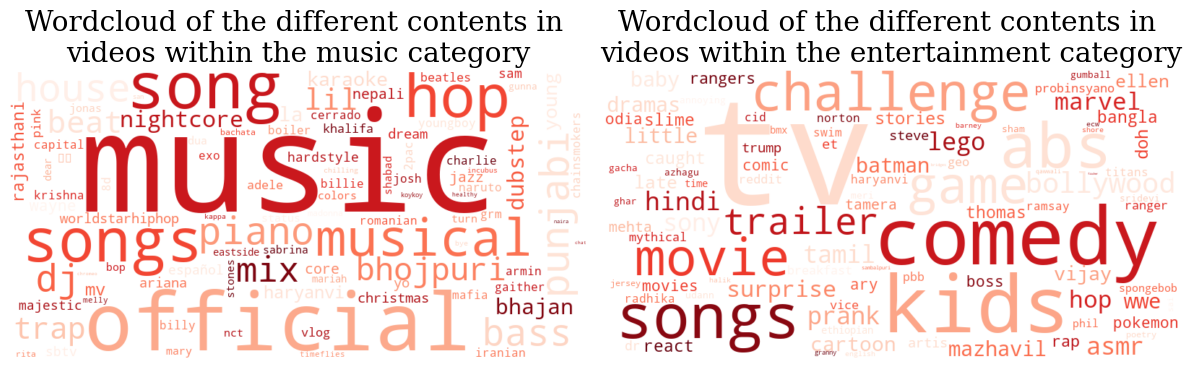

In [12]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the wordclouds of clusters for Music and Entertainment categories
for i, (key, df) in enumerate(dataframes_clusterized.items()):
    diversity_utils.plot_word_frequency(df, column='Cluster Name', title=f"Wordcloud of the different contents in \nvideos within the {key.split('_')[-1]} category", ax=axes[i])

# Save and show the figure
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'wordcloud_music_vs_entertainment_general.pdf'), format="pdf", bbox_inches="tight")
plt.show()

## 2. Tokenization of the clusters

Next, with the clusters identified, we aim to extract feature representations to calculate distances. Our ultimate goal is to compute the average distance between all clusters within a category, which will serve as our diversity score. To achieve this, we use a pre-trained embedding model called GloVe. GloVe provides 6 billion tokens, 400K words in the vocabulary, and generates 300-dimensional feature vectors for each word.

We then set multiple time granularities (days, months, and years) and group the data frames by them to analyze the evolution of the diversity score over time. This approach allows us to observe trends and patterns in diversity across different time scales.

In [20]:
# Load the GloVe embeddings
glove_6B_300d = diversity_utils.load_glove_embeddings('glove.6B.300d.txt')

In [66]:
avg_distance = {}

# Compute the average distance between the clusters for all videos in Music and Entertainment categories
for key, df in dataframes_clusterized.items():
    avg_distance[key] = diversity_utils.calculate_diversity_with_glove(df, embeddings=glove_6B_300d)

for key, value in avg_distance.items():
    print(f"The average distance between the clusters in the {key.split('_')[-1]} category is {value:.5f}")

The average distance between the clusters in the music category is 0.95619
The average distance between the clusters in the entertainment category is 0.95626


In [57]:
split_dataframes_days = {}
split_dataframes_months = {}
split_dataframes_years = {}

# Split the dataframes by days
for key, df in dataframes_clusterized.items():
    split_dataframes_days[key] = diversity_utils.split_df_by_timeframe(df, timeframe='day')

# Split the dataframes by months
for key, df in dataframes_clusterized.items():
    split_dataframes_months[key] = diversity_utils.split_df_by_timeframe(df, timeframe='month')

# Split the dataframes by years
for key, df in dataframes_clusterized.items():
    split_dataframes_years[key] = diversity_utils.split_df_by_timeframe(df, timeframe='year')

## 3. Average cluster distance

We compute the minimum distance between clusters in Music and Entertainment to define our diversity score. This choice is based on the observation that when clusters are far apart in the embedding space, it indicates greater diversity, meaning the diversity score should be high. Conversely, when clusters are close to each other, the diversity score should be low, as it reflects less variation among the clusters. This metric captures how distinct or overlapping the clusters are within the embedding space, providing a meaningful representation of diversity.

In [58]:
avg_distances_days = {}
avg_distances_days_dataframes = {}

# Compute the average distance between the clusters for each month in the Music and Entertainment categories
for key, df_split in split_dataframes_days.items():
    avg_distances_days[key] = {}
    for month, df in df_split.items():
        avg_distances_days[key][month] = diversity_utils.calculate_diversity_with_glove(df, embeddings=glove_6B_300d)
 
for key, avg_distance in avg_distances_days.items():
    avg_distances_days_dataframes[key] = pd.DataFrame.from_dict(avg_distance, orient='index').reset_index().rename(columns={'index': 'date', 0: 'diversity_score'})
    avg_distances_days_dataframes[key]['date'] = pd.to_datetime(avg_distances_days_dataframes[key]['date'], format='mixed')


avg_distances_months = {}
avg_distances_months_dataframes = {}

# Compute the average distance between the clusters for each month in the Music and Entertainment categories
for key, df_split in split_dataframes_months.items():
    avg_distances_months[key] = {}
    for month, df in df_split.items():
        avg_distances_months[key][month] = diversity_utils.calculate_diversity_with_glove(df, embeddings=glove_6B_300d)
 
for key, avg_distance in avg_distances_months.items():
    avg_distances_months_dataframes[key] = pd.DataFrame.from_dict(avg_distance, orient='index').reset_index().rename(columns={'index': 'date', 0: 'diversity_score'})
    avg_distances_months_dataframes[key]['date'] = pd.to_datetime(avg_distances_months_dataframes[key]['date'], format='mixed')


avg_distances_years = {}
avg_distances_years_dataframes = {}

# Compute the average distance between the clusters for each year in the Music and Entertainment categories
for key, df_split in split_dataframes_years.items():
    avg_distances_years[key] = {}
    for year, df in df_split.items():
        avg_distances_years[key][year] = diversity_utils.calculate_diversity_with_glove(df, embeddings=glove_6B_300d)
 
for key, avg_distance in avg_distances_years.items():
    avg_distances_years_dataframes[key] = pd.DataFrame.from_dict(avg_distance, orient='index').reset_index().rename(columns={'index': 'date', 0: 'diversity_score'})
    avg_distances_years_dataframes[key]['date'] = pd.to_datetime(avg_distances_years_dataframes[key]['date'], format='mixed')

## 4. Diversity score evolution over time

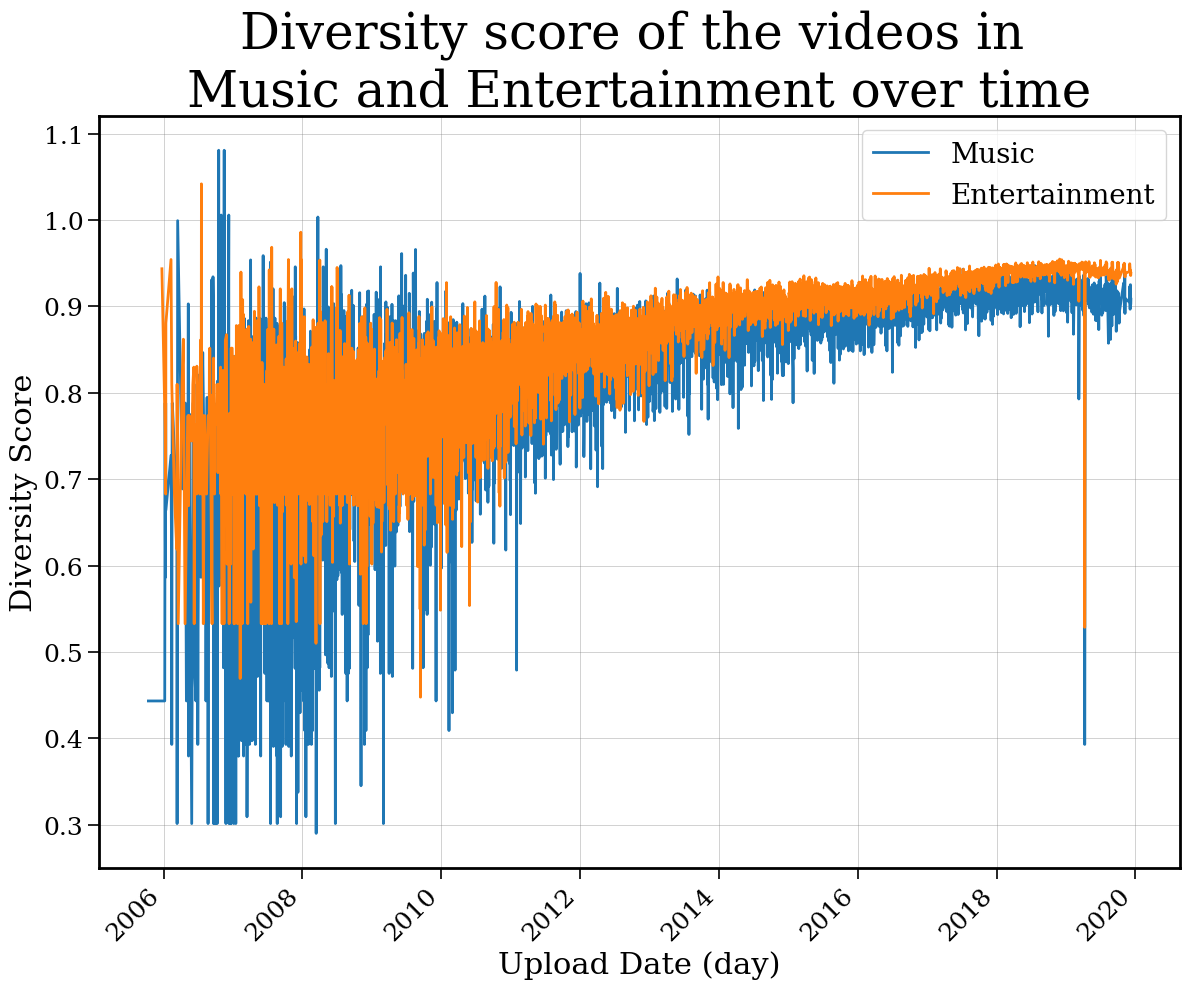

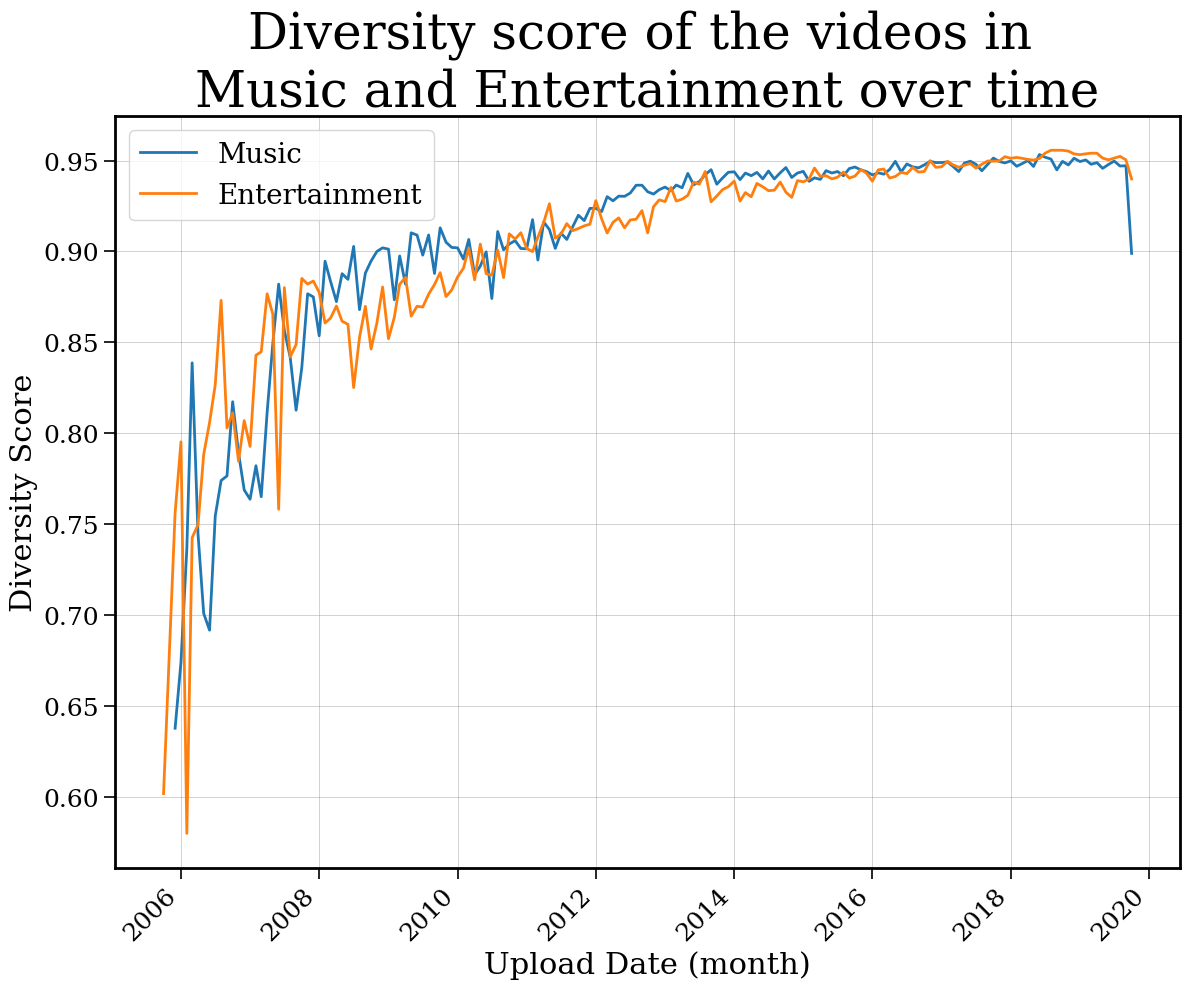

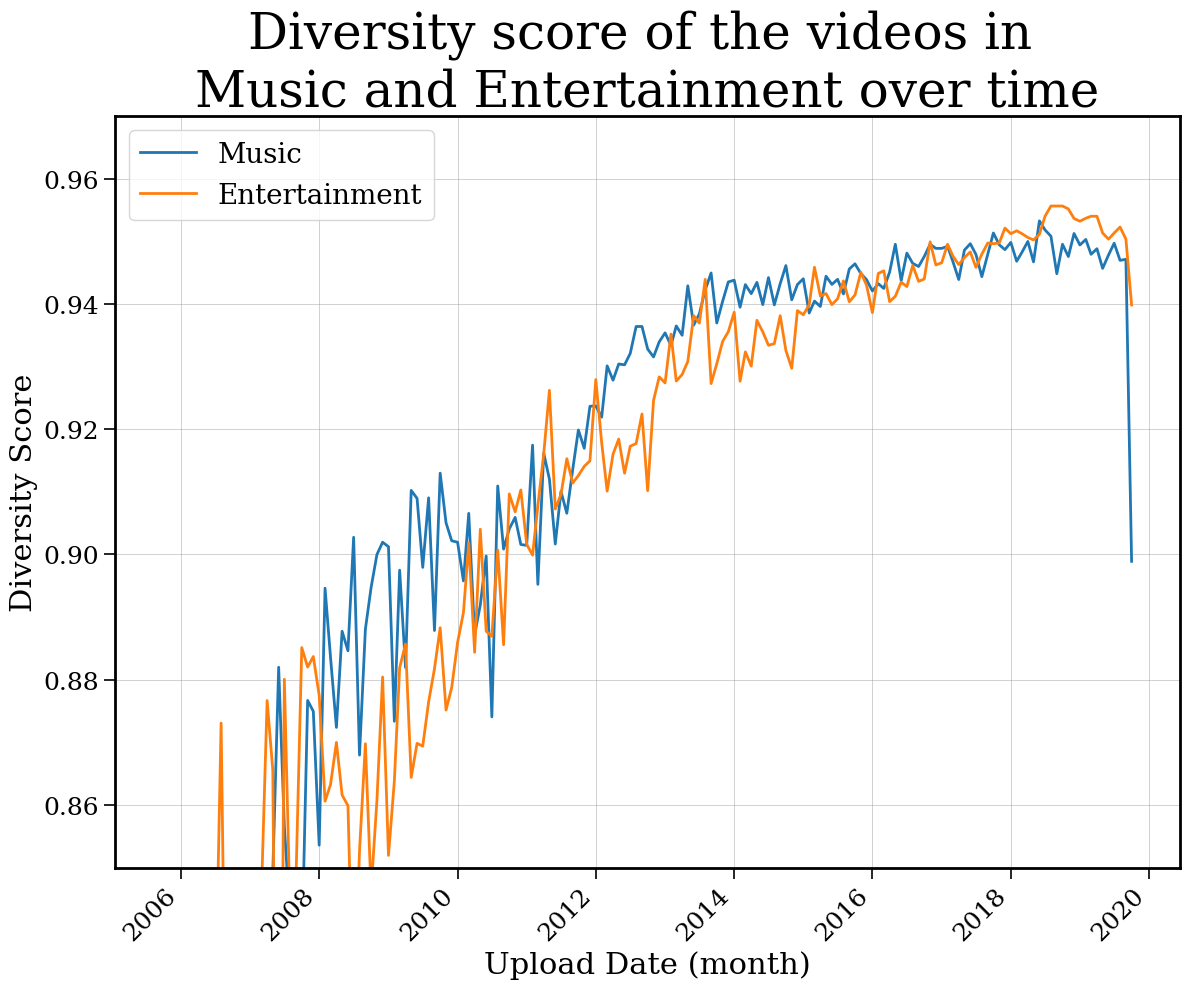

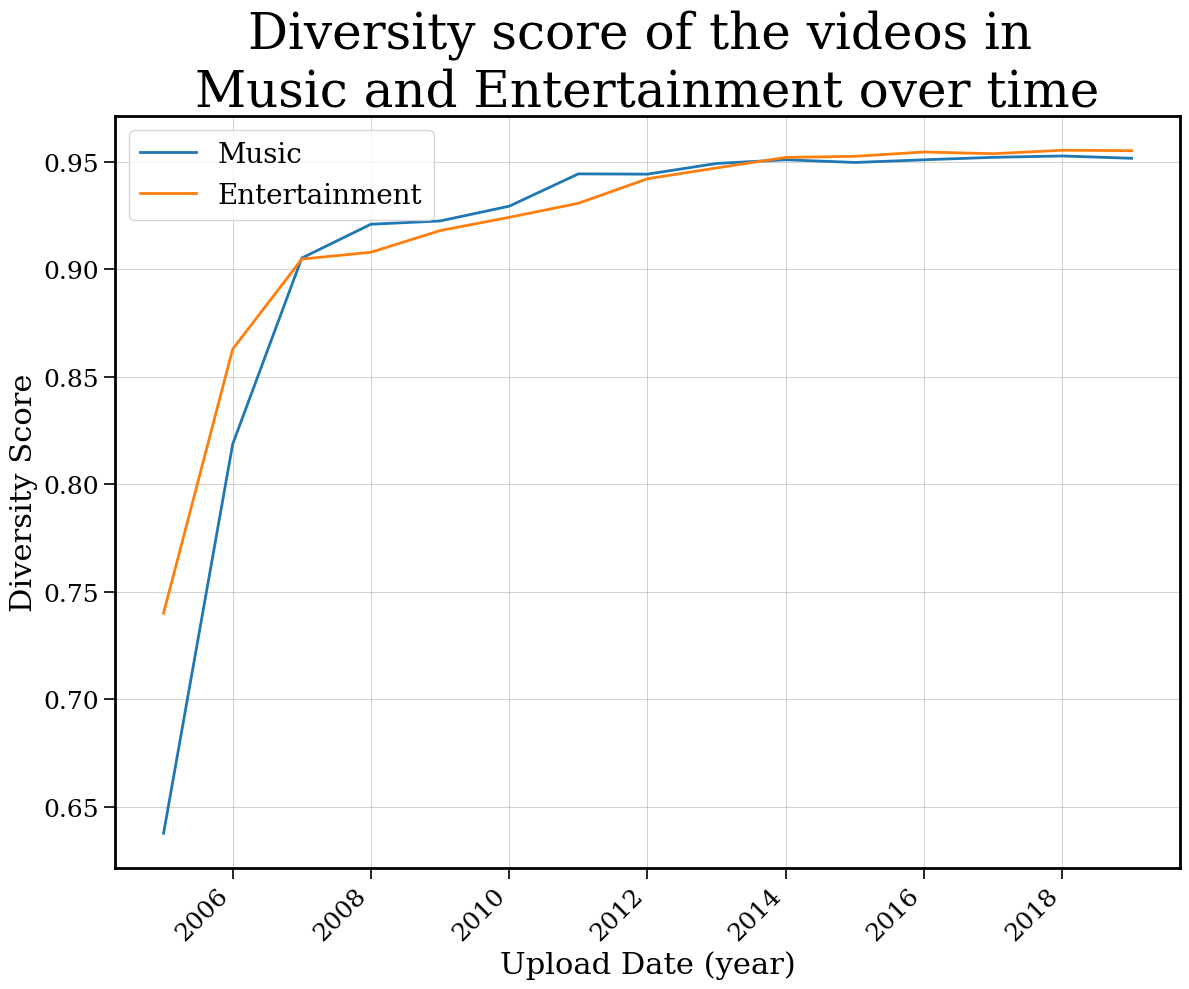

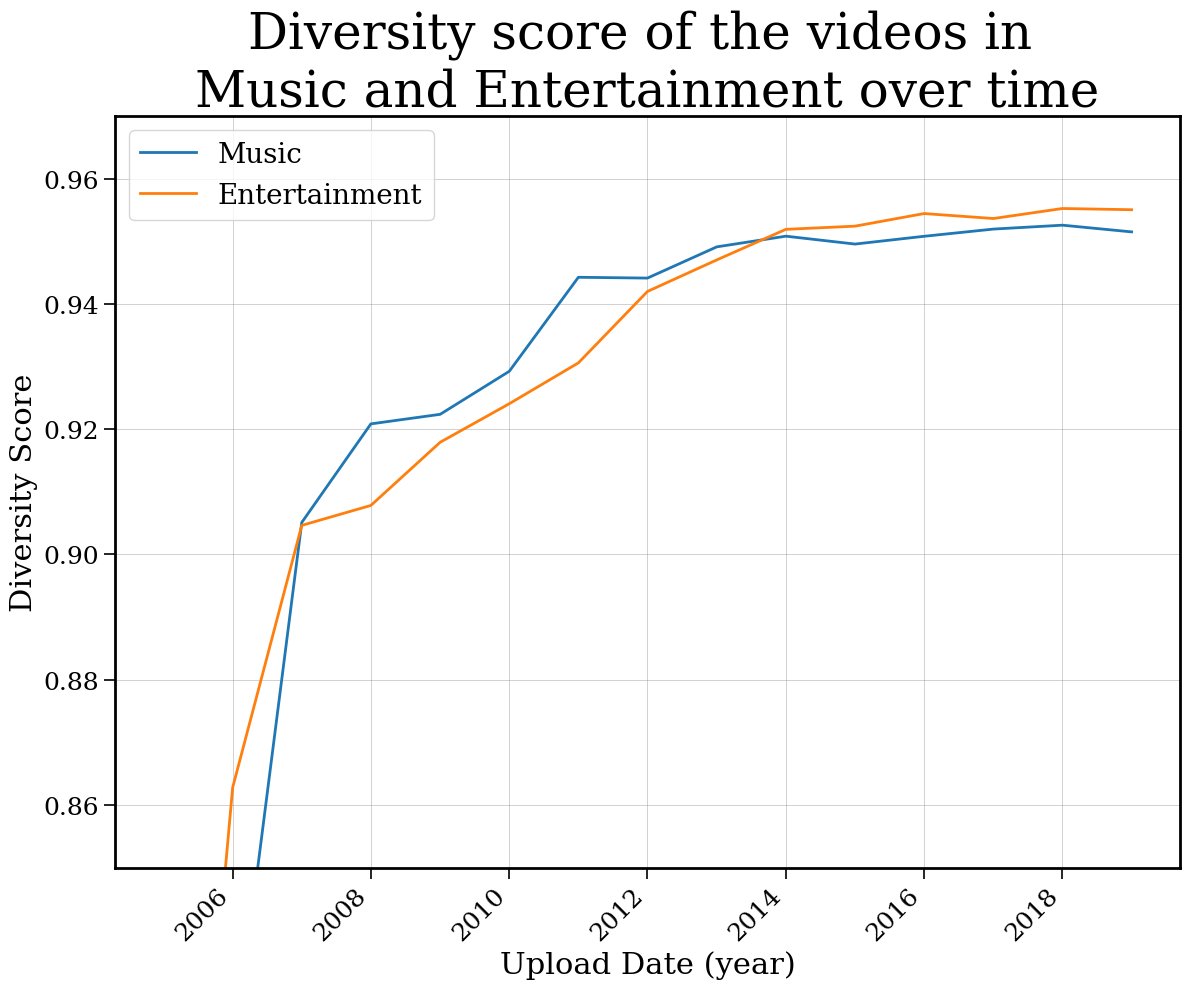

In [63]:
diversity_utils.plot_diversity(avg_distances_days_dataframes.values(), title='Diversity score of the videos in \nMusic and Entertainment over time', y_limit=None, labels=['Music', 'Entertainment'], time_granularity='day', filename=os.path.join(FIGURES_PATH, 'diversity_music_vs_entertainment_days.pdf'))
diversity_utils.plot_diversity(avg_distances_months_dataframes.values(), title='Diversity score of the videos in \nMusic and Entertainment over time', y_limit=None, labels=['Music', 'Entertainment'], time_granularity='month', filename=os.path.join(FIGURES_PATH, 'diversity_music_vs_entertainment_months.pdf'))
diversity_utils.plot_diversity(avg_distances_months_dataframes.values(), title='Diversity score of the videos in \nMusic and Entertainment over time', y_limit=(0.85,0.97), labels=['Music', 'Entertainment'], time_granularity='month', filename=os.path.join(FIGURES_PATH, 'diversity_music_vs_entertainment_months.pdf'))
diversity_utils.plot_diversity(avg_distances_years_dataframes.values(), title='Diversity score of the videos in \nMusic and Entertainment over time', y_limit=None, labels=['Music', 'Entertainment'], time_granularity='year', filename=os.path.join(FIGURES_PATH, 'diversity_music_vs_entertainment_years.pdf'))
diversity_utils.plot_diversity(avg_distances_years_dataframes.values(), title='Diversity score of the videos in \nMusic and Entertainment over time', y_limit=(0.85,0.97), labels=['Music', 'Entertainment'], time_granularity='year', filename=os.path.join(FIGURES_PATH, 'diversity_music_vs_entertainment_years_zoom.pdf'))

#### **OBSERVATIONS**
<div style="background-color: #D8EAD8; border-left:3px solid green; padding: 10px; border-radius: 5px;">
For both categories, there is a noticeable upward trend in the Diversity Score from 2006 to 2020. This suggests that, over time, YouTube content has generally expanded to encompass a broader spectrum of diversity.<br><br>
When analyzing the daily fluctuations of the Diversity Score for videos in the Music and Entertainment categories over time, we observe significant initial variability. The Music category, in particular, exhibits larger fluctuations. However, there is no clear trend indicating whether one category consistently surpasses the other in terms of diversity.<br><br>
When considering a less granular and more aggregated time period, a trend emerges: the Entertainment category initially exhibits lower diversity compared to Music until around 2016, after which it surpasses the Music category in terms of diversity.
</div>

## 5. Distribution of diversity scores for channels within each categories

In [48]:
channel_ids = {}

# Get the unique channel ids for Music and Entertainment categories
for key, df in dataframes.items():
    channel_ids[key] = df['channel_id'].unique()

In [49]:
diversities = {}
for key in channel_ids.keys():
    channel_ids[key] = channel_ids[key][:1000]
    
# Compute the average distance between the clusters for each channel in the Music and Entertainment categories
for key, df in dataframes.items():
    diversities[key] = []
    for id in tqdm(channel_ids[key]):
        # Get the video metadata for the channel id
        video_metadata_for_id = df[df['channel_id'] == id]

        # Cluster the video metadata for the channel id
        video_metadata_for_id = diversity_utils.get_clusters_from_df(video_metadata_for_id, text_column=['title', 'tags'], num_clusters=min(len(video_metadata_for_id), 25), min_df=1, max_df=1.0)
        
        # Get embeddings for the clusters
        embeddings = diversity_utils.tokenize_list(video_metadata_for_id, glove_6B_300d)

        # Compute the average distance between the clusters
        diversity = diversity_utils.calculate_diversity(embeddings)
        diversities[key].append(diversity)
        #print(f"The average distance between the clusters in the channel {id} is {diversity:.5f}")

 27%|██▋       | 269/1000 [00:19<00:50, 14.45it/s]/opt/miniconda3/envs/ADA/lib/python3.11/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (22) found smaller than n_clusters (23). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
 54%|█████▍    | 543/1000 [00:40<00:37, 12.29it/s]/opt/miniconda3/envs/ADA/lib/python3.11/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
 64%|██████▍   | 641/1000 [00:48<00:23, 15.36it/s]/opt/miniconda3/envs/ADA/lib/python3.11/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
 66%|██████▌   | 659/1000 [00:49<00:29, 11.58it/s]/opt/miniconda3/envs/ADA/lib/python3.11/site-pac

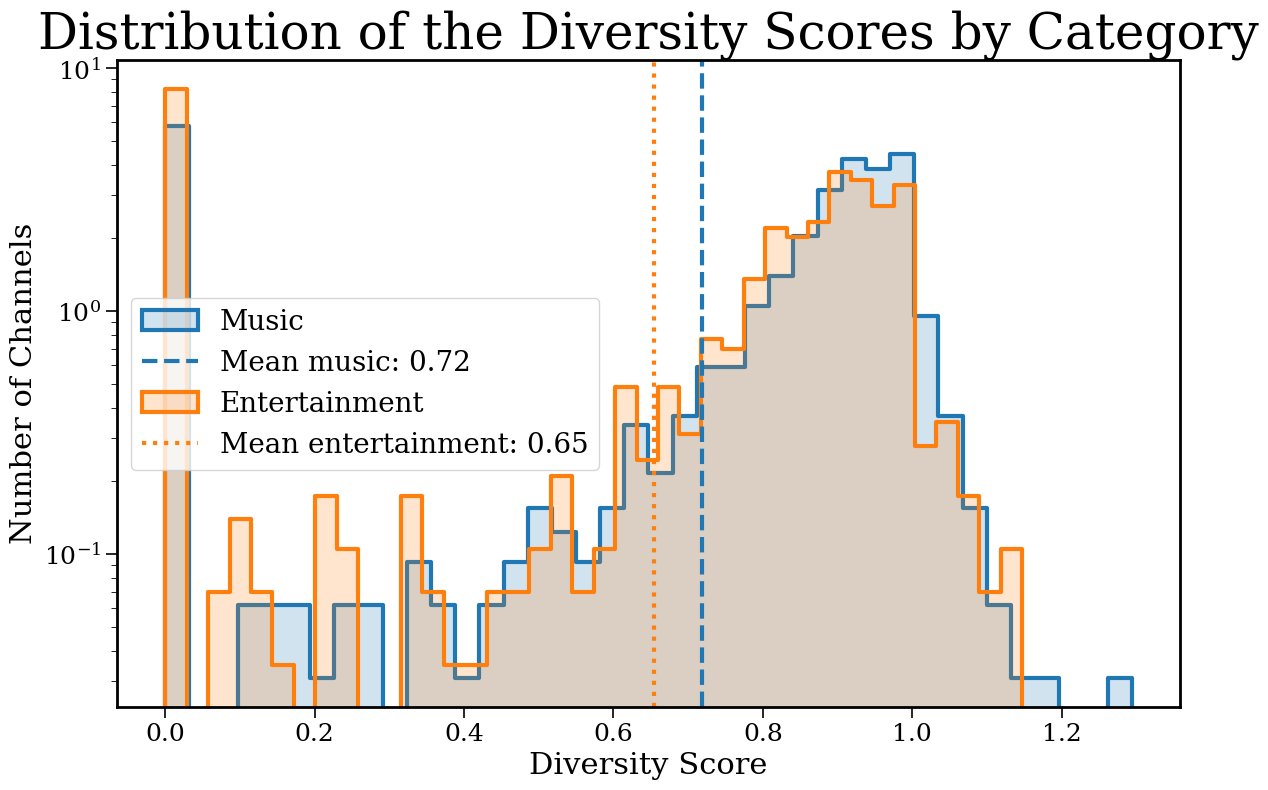

In [56]:
diversity_utils.plot_diversity_histogram(diversities, filename=os.path.join(FIGURES_PATH, 'diversity_histogram.pdf'))